### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn import metrics
from sklearn.cluster import DBSCAN

from ml_homework.clustering import (
    evaluate_kmeans,
    fit_kmeans,
    summarize_customer_clusters,
)
from ml_homework.eda import get_columns_summary, iqr_bounds
from ml_homework.paths import RAW_DATA_DIR
from ml_homework.preprocessing import (
    get_numerical_and_categorical_columns,
    prepare_clustering_features,
)
from ml_homework.preprocessing.customer_marketing import prepare_cluster_viz_df
from ml_homework.visualization.clustering import (
    plot_clusters,
    plot_customer_clusters,
    plot_elbow,
)

ImportError: cannot import name 'summarize_customer_clusters' from 'ml_homework.clustering' (/Users/olharyzha/Desktop/courses/ml/lessons/my_ml_home_work/src/ml_homework/clustering.py)

In [ ]:
N_CLUSTERS = 3
RANDOM_STATE = 42
N_INIT = 10

In [ ]:
raw_df = pd.read_csv(RAW_DATA_DIR / "marketing/marketing_campaign.csv", sep="\t").copy()

In [ ]:
raw_df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [ ]:
raw_df.shape

(2240, 29)

In [ ]:
raw_df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [ ]:
missing = raw_df.isna().sum()

missing[missing > 0]

Income    24
dtype: int64

In [ ]:
raw_df["Income"].sort_values(ascending=False).head(10)

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64

In [ ]:
lower, upper = iqr_bounds(raw_df["Income"])

raw_df[(raw_df["Income"] < lower) | (raw_df["Income"] > upper)][["Income"]]

,Income
164,157243.0
617,162397.0
655,153924.0
687,160803.0
1300,157733.0
1653,157146.0
2132,156924.0
2233,666666.0


In [ ]:
raw_df = raw_df[raw_df["Income"] != 666666].copy()

За правилом IQR я виявила 8 потенційних викидів в колонці Income. Значення близько 153–162 тис. я вирішила залишити, оскільки вони можуть представляти реальних клієнтів із високим доходом, а от значення 666666 значно відрізняється від решти розподілу, тому його видалила як аномальне.

<Axes: >

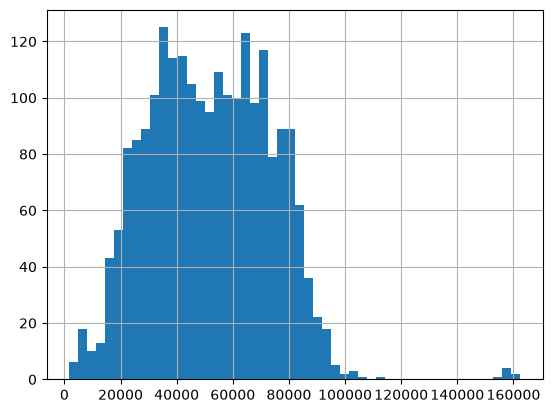

In [ ]:
raw_df["Income"].hist(bins=50)

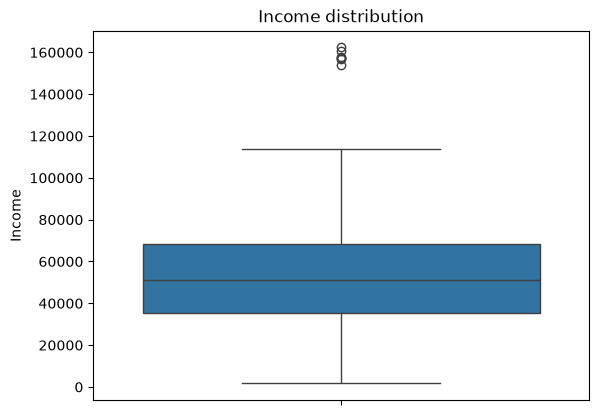

In [ ]:
sns.boxplot(data=raw_df, y="Income")
plt.title("Income distribution")
plt.show()

In [ ]:
raw_df["Income"] = raw_df["Income"].fillna(raw_df["Income"].median())

In [ ]:
raw_df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [ ]:
raw_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,...,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.000000,2239.0,2239.0,2239.000000
mean,5590.444841,1968.802144,51963.463600,0.443948,0.506476,49.121036,304.067441,26.307727,167.016525,37.538633,...,5.316213,0.072800,0.074587,0.072800,0.064314,0.013399,0.009379,3.0,11.0,0.149174
std,3246.372471,11.985494,21410.674611,0.538390,0.544555,28.963662,336.614830,39.781468,225.743829,54.637617,...,2.427144,0.259867,0.262782,0.259867,0.245367,0.115001,0.096412,0.0,0.0,0.356339
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2827.500000,1959.000000,35533.500000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5455.000000,1970.000000,51373.000000,0.000000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8423.500000,1977.000000,68277.500000,1.000000,1.000000,74.000000,504.500000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,162397.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
corr = raw_df.drop(columns="ID").corr(numeric_only=True)

corr

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
Year_Birth,1.000000,-0.196990,0.229939,-0.351932,-0.019601,-0.157548,-0.017825,-0.030677,-0.041467,-0.017943,...,0.121068,0.061868,-0.060430,0.007209,-0.005851,-0.006504,-0.030101,NaN,NaN,0.021456
Income,-0.196990,1.000000,-0.510858,0.034113,0.006812,0.686147,0.505524,0.684375,0.518775,0.518275,...,-0.646694,-0.015196,0.217364,0.395315,0.324898,0.103936,-0.030552,NaN,NaN,0.160787
Kidhome,0.229939,-0.510858,1.000000,-0.035720,0.009246,-0.496096,-0.372535,-0.436972,-0.387512,-0.370503,...,0.447831,0.014807,-0.161511,-0.205557,-0.172261,-0.081682,0.040261,NaN,NaN,-0.079837
Teenhome,-0.351932,0.034113,-0.035720,1.000000,0.015829,0.004484,-0.176930,-0.261510,-0.204465,-0.162783,...,0.135029,-0.042802,0.038777,-0.191206,-0.140228,-0.015656,0.003098,NaN,NaN,-0.154655
Recency,-0.019601,0.006812,0.009246,0.015829,1.000000,0.015716,-0.004431,0.022797,0.000861,0.022421,...,-0.021335,-0.033110,0.018715,0.000016,-0.019392,-0.001829,0.013194,NaN,NaN,-0.198649
MntWines,-0.157548,0.686147,-0.496096,0.004484,0.015716,1.000000,0.389591,0.562559,0.399636,0.386435,...,-0.320603,0.062104,0.373246,0.472593,0.354097,0.205897,-0.039052,NaN,NaN,0.247143
MntFruits,-0.017825,0.505524,-0.372535,-0.176930,-0.004431,0.389591,1.000000,0.543078,0.594780,0.567139,...,-0.418360,0.014689,0.010113,0.215802,0.194719,-0.009790,-0.005180,NaN,NaN,0.125239
MntMeatProducts,-0.030677,0.684375,-0.436972,-0.261510,0.022797,0.562559,0.543078,1.000000,0.568335,0.523758,...,-0.539449,0.018191,0.102840,0.373729,0.309718,0.043003,-0.023514,NaN,NaN,0.236244
MntFishProducts,-0.041467,0.518775,-0.387512,-0.204465,0.000861,0.399636,0.594780,0.568335,1.000000,0.579807,...,-0.445972,0.000290,0.016776,0.199527,0.260720,0.002549,-0.020978,NaN,NaN,0.111241
MntSweetProducts,-0.017943,0.518275,-0.370503,-0.162783,0.022421,0.386435,0.567139,0.523758,0.579807,1.000000,...,-0.423260,0.001451,0.028564,0.259539,0.241769,0.009953,-0.022514,NaN,NaN,0.117269


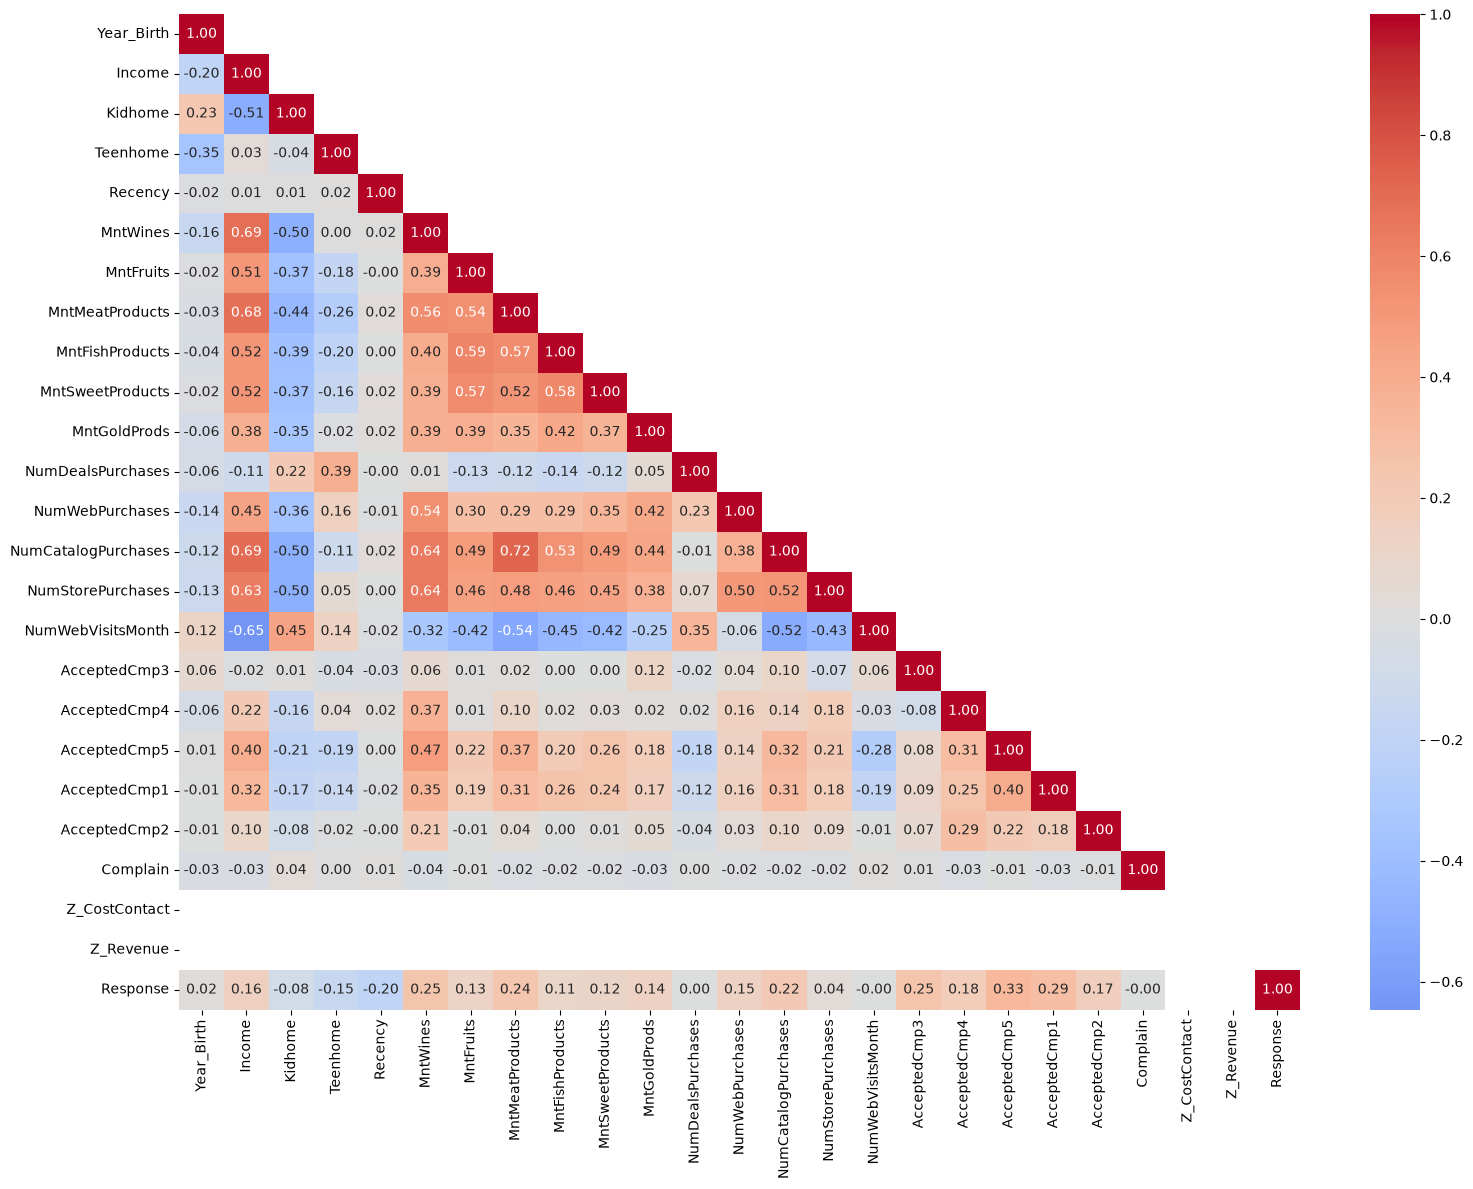

In [ ]:
mask = np.triu(
    np.ones_like(corr, dtype=bool),
    k=1,
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.tight_layout()
plt.show()

In [ ]:
raw_df[["Z_CostContact", "Z_Revenue"]].nunique()

Z_CostContact    1
Z_Revenue        1
dtype: int64

In [ ]:
raw_df = raw_df.drop(columns=["Z_CostContact", "Z_Revenue", "ID"])

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

Заповнила пропущені значення в колонці Income в попередньому завданні медіаною, в даних присутні викиди, а медіана є менш чутливою до них, ніж середнє значення.
Видалила колонки Z_CostContact та Z_Revenue, бо вони не несуть корисної інформації для кластеризації.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [ ]:
cat_cols = raw_df.select_dtypes(include=["object", "str"]).columns
cat_cols

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='str')

In [ ]:
get_columns_summary(data=raw_df, columns=cat_cols)

,column,nunique,unique_values
0,Education,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
1,Marital_Status,8,"[Single, Together, Married, Divorced, Widow, A..."
2,Dt_Customer,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-201..."


In [ ]:
raw_df["Education"].value_counts()

Education
Graduation    1126
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [ ]:
raw_df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    579
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [ ]:
raw_df["Dt_Customer"].value_counts()

Dt_Customer
31-08-2012    12
12-05-2014    11
12-09-2012    11
14-02-2013    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 663, dtype: int64

In [ ]:
raw_df["Dt_Customer"] = pd.to_datetime(
    raw_df["Dt_Customer"],
    format="%d-%m-%Y",
)

reference_date = raw_df["Dt_Customer"].max()

raw_df["Customer_Tenure_Days"] = (reference_date - raw_df["Dt_Customer"]).dt.days

raw_df = raw_df.drop(
    columns=["Dt_Customer"],
)

In [ ]:
raw_df["Marital_Status"] = raw_df["Marital_Status"].replace(
    {
        "Alone": "Single",
        "Absurd": "Other",
        "YOLO": "Other",
    }
)

In [ ]:
num_cols, cat_cols = get_numerical_and_categorical_columns(raw_df)

In [ ]:
X = prepare_clustering_features(raw_df, cat_cols)

Категоріальні ознаки `Education` та `Marital_Status` перетворила за допомогою One-Hot Encoding, оскільки алгоритми кластеризації працюють з числовими ознаками.

А такі рідкісні значення як "Alone", "Absurd", "YOLO" в `Marital_Status` об'єднала з більш змістовними категоріями.

Колонку `Dt_Customer` перетворила в `Customer_Tenure_Days`, що показує, як довго клієнт був зареєстрований у компанії на момент останньої дати в датасеті.

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [ ]:
kmeans, labels, s = fit_kmeans(
    X,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)

In [ ]:
print(f"Silhouette without scaling: {s:.3f}")

Silhouette without scaling: 0.544


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [ ]:
viz_df = prepare_cluster_viz_df(
    raw_df,
    labels,
)

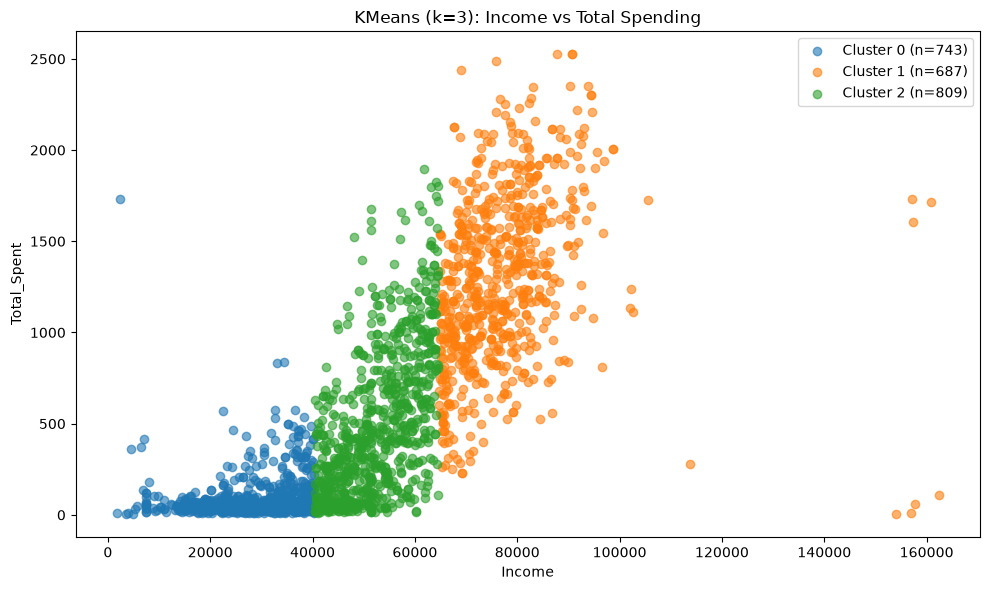

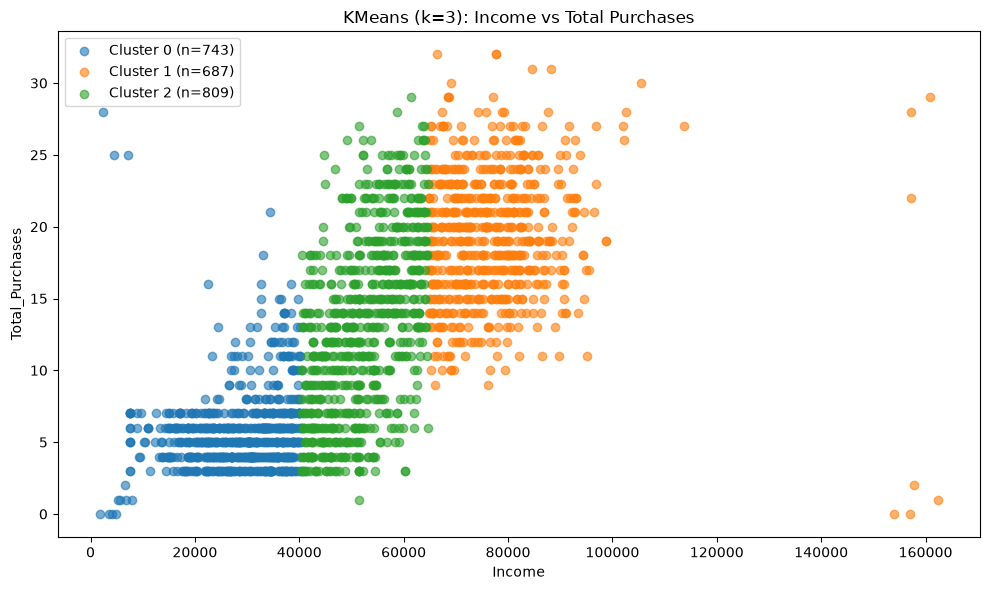

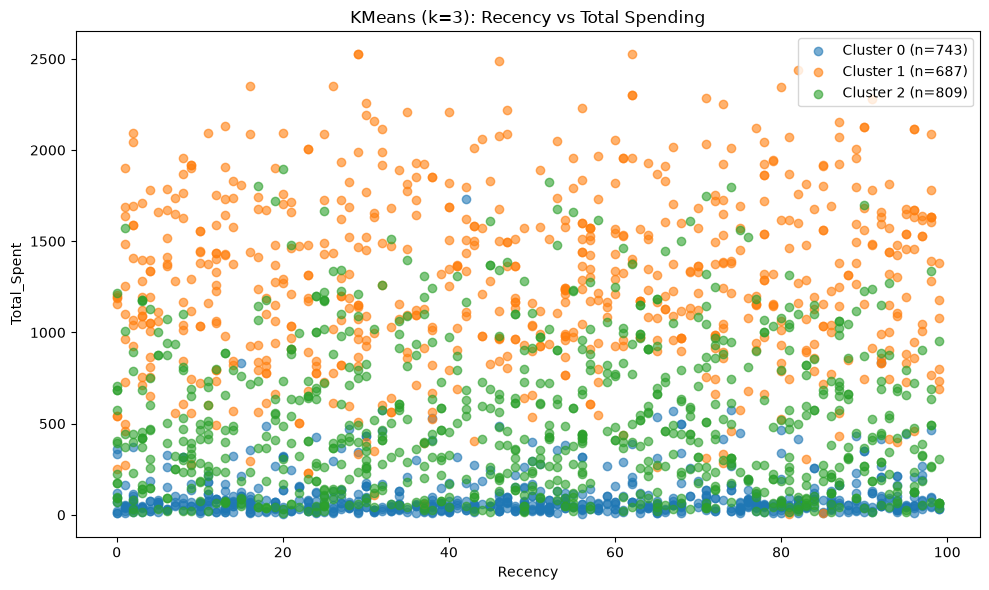

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
0              743    28380.376      94.989           5.769           0.016
1              687    76967.844    1283.719          19.255           0.007
2              809    52388.958     499.918          13.056           0.005


In [ ]:
plot_customer_clusters(viz_df, title="KMeans (k=3)")
print(summarize_customer_clusters(viz_df).round(3))

Без масштабування групи досить чітко розділяються за доходом, який домінує у відстанях через великий масштаб.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [ ]:
X_scaled = prepare_clustering_features(raw_df, cat_cols, scale_numeric=True)

In [ ]:
kmeans_scaled, labels_scaled, silhouette_scaled = fit_kmeans(
    X_scaled,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)
print(f"Silhouette with scaling: {silhouette_scaled:.3f}")

Silhouette with scaling: 0.163


In [ ]:
viz_df_scaled = prepare_cluster_viz_df(
    raw_df,
    labels_scaled,
)

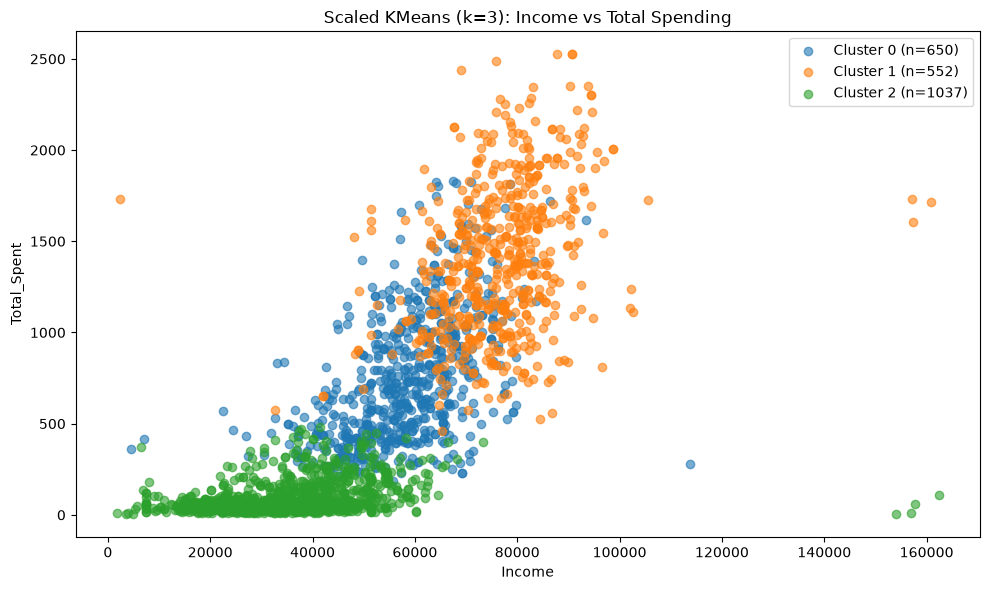

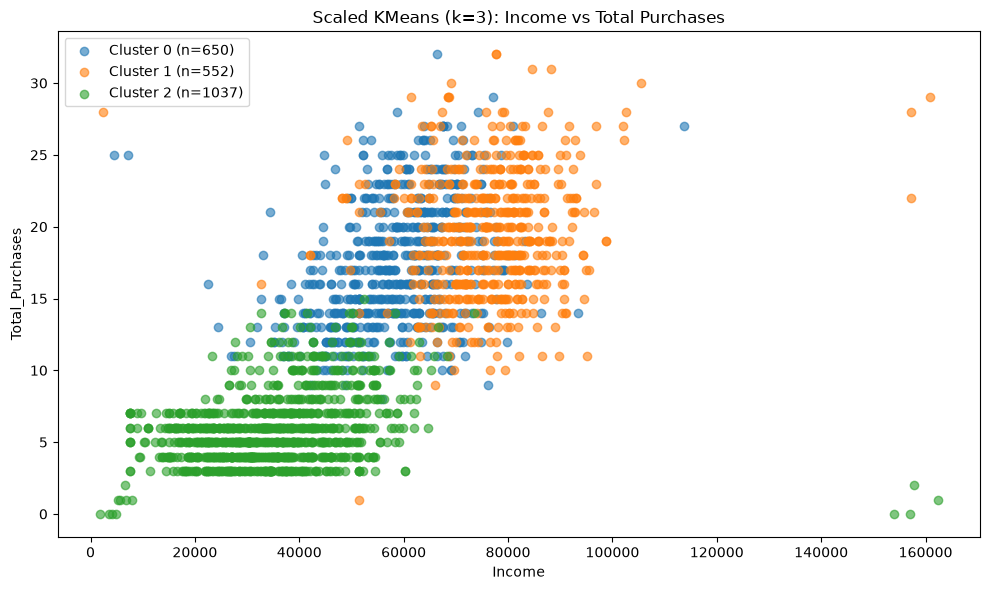

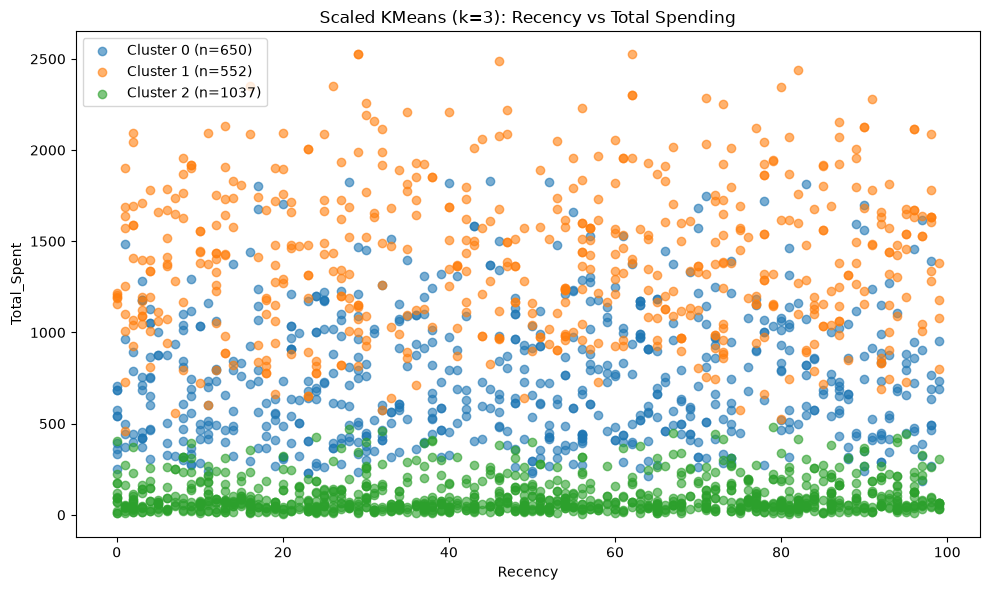

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
0              650    58107.488     740.922          17.283           0.009
1              552    76582.076    1402.678          19.489           0.004
2             1037    35007.736      97.444           5.867           0.013


In [ ]:
plot_customer_clusters(viz_df_scaled, title="Scaled KMeans (k=3)")
print(summarize_customer_clusters(viz_df_scaled).round(3))

Після масштабування отримано три групи з 650, 552 і 1037 клієнтів із середніми доходами приблизно 58, 77 і 35 тис.

Силует становить близько 0.16, це значно менше як 0.54 у попередньому результаті, але масштабування змінює відстані між клієнтами, тому результати силуету не можна прямо порівнювати як оцінку в однакових умовах.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

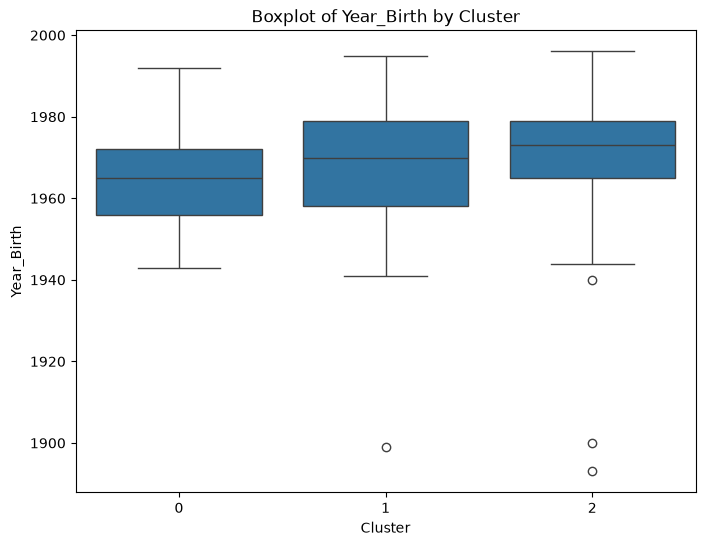

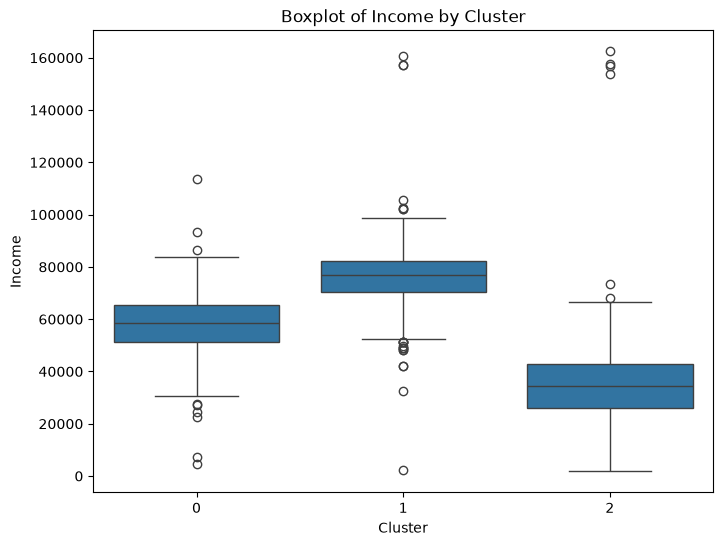

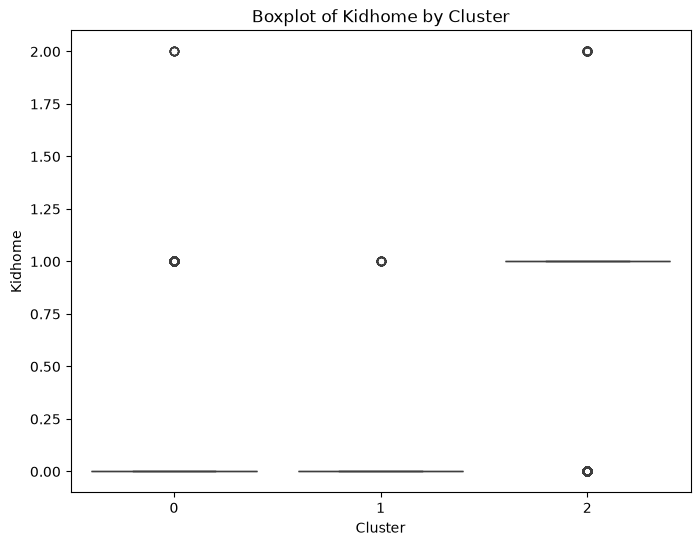

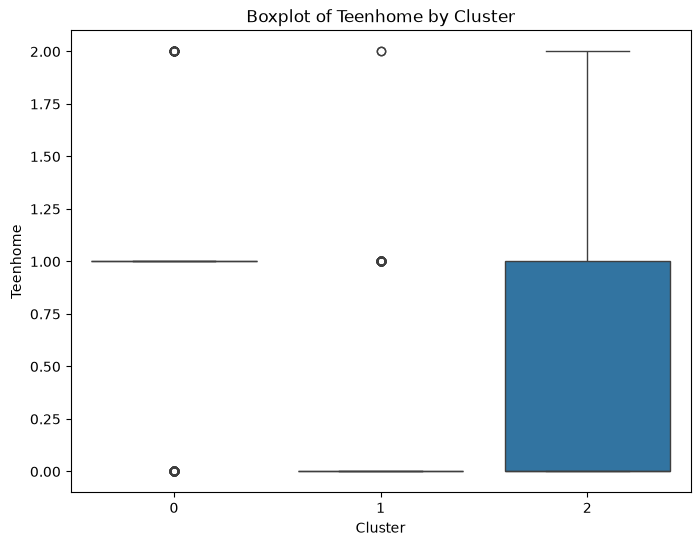

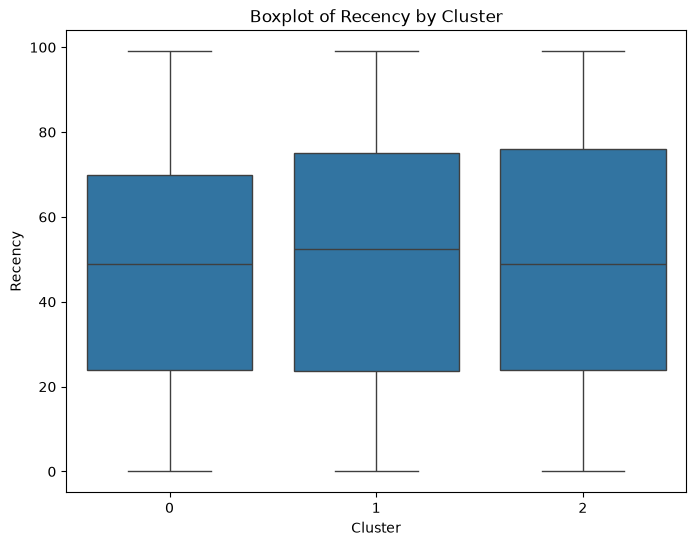

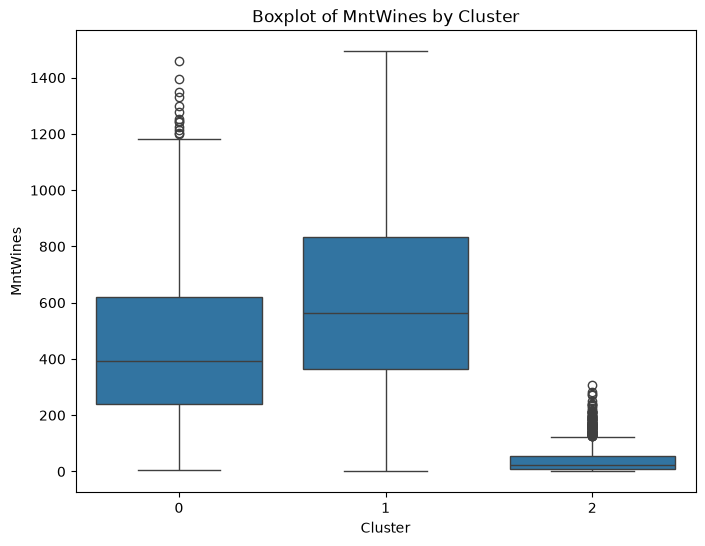

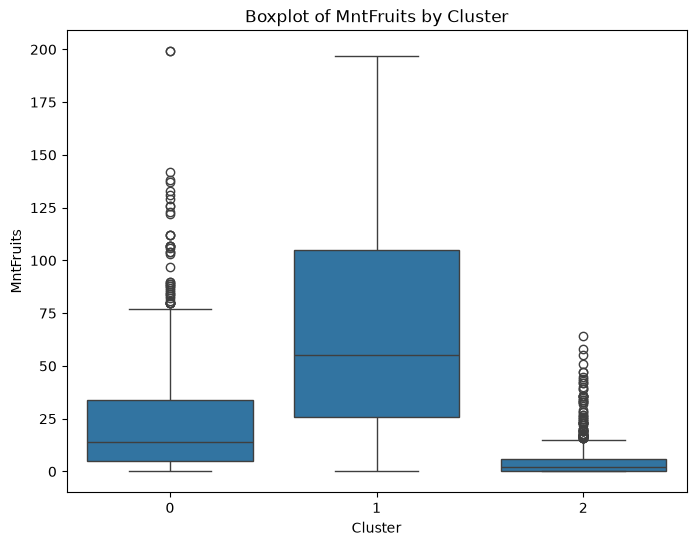

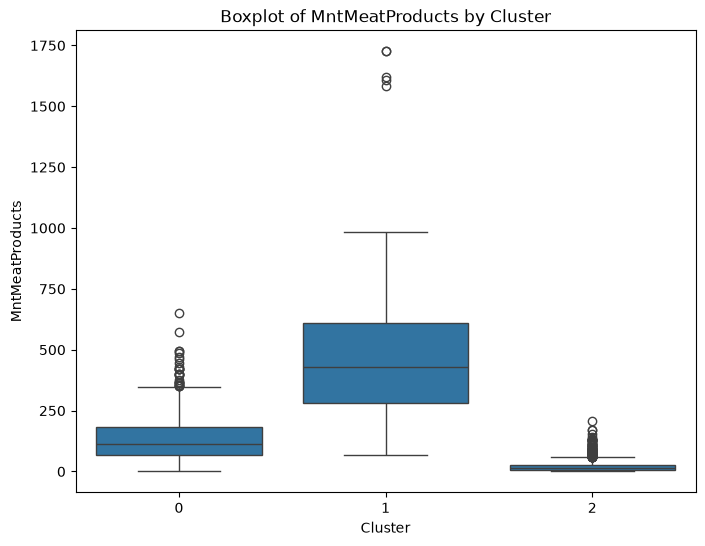

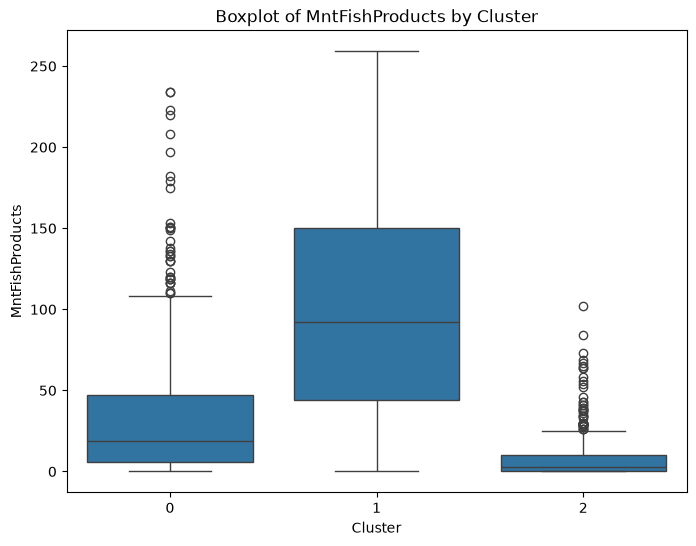

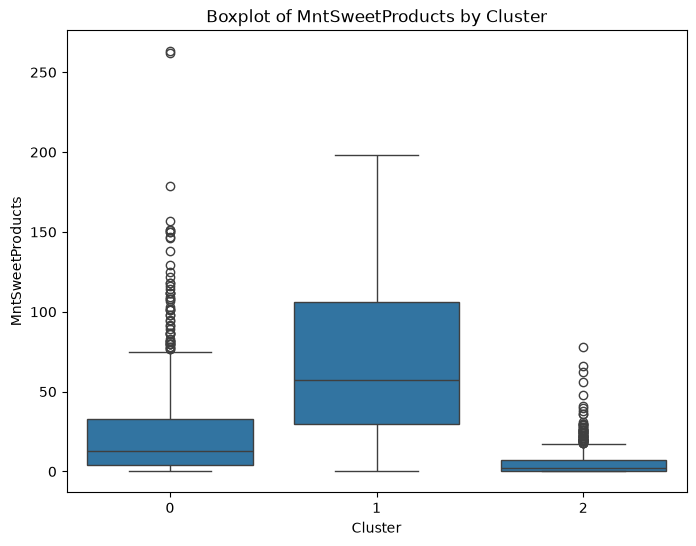

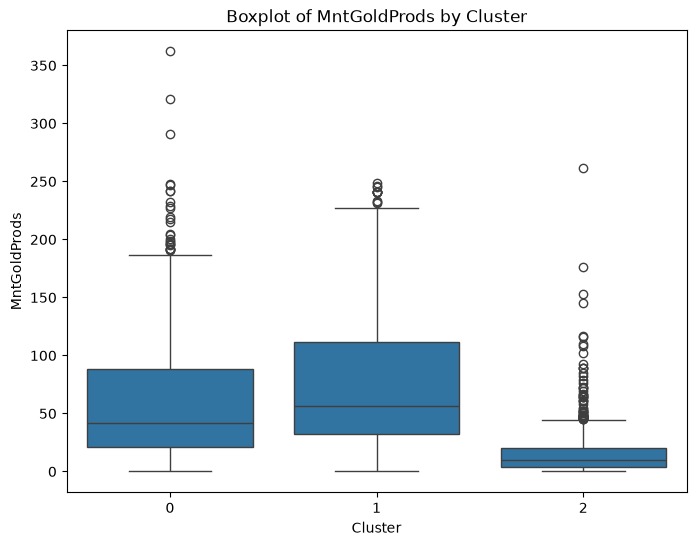

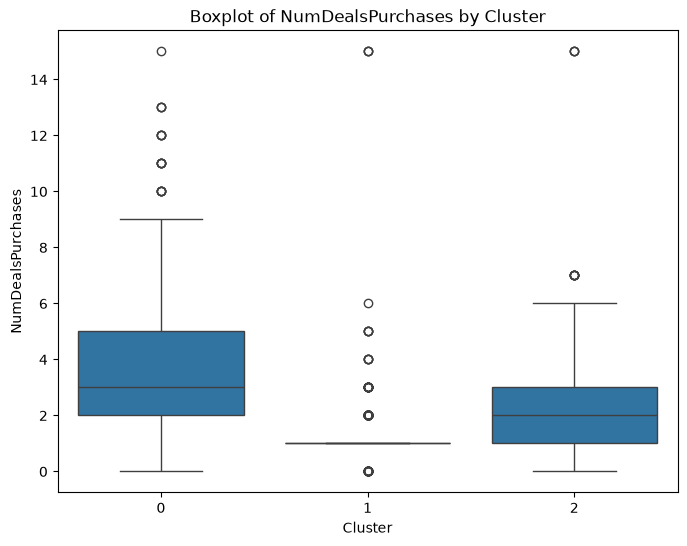

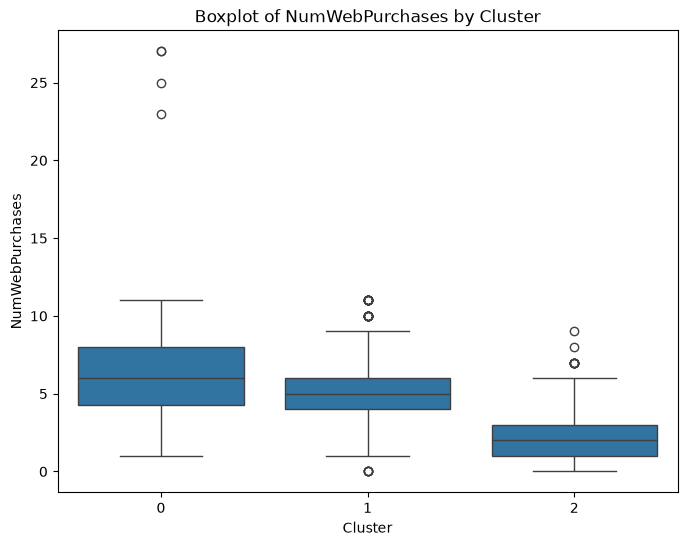

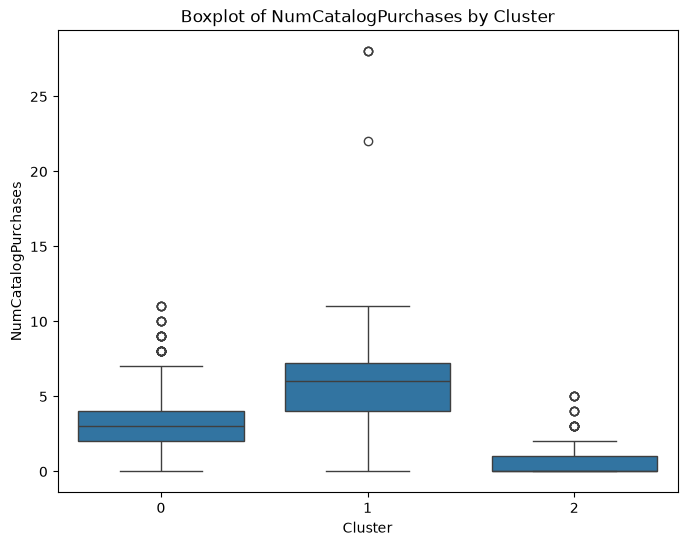

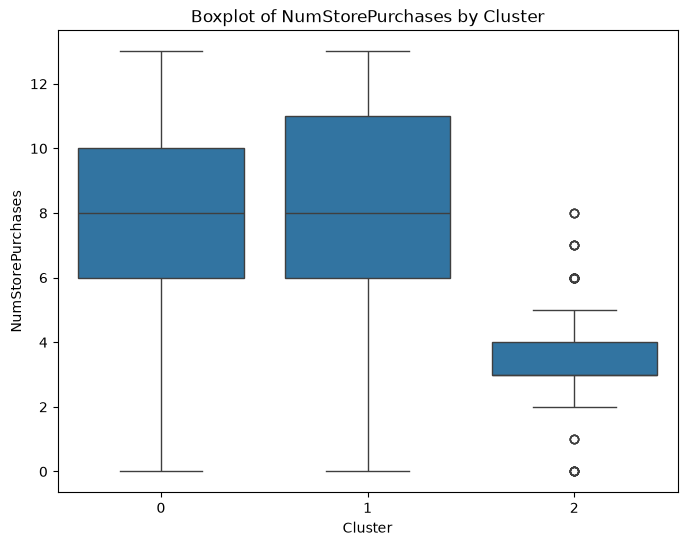

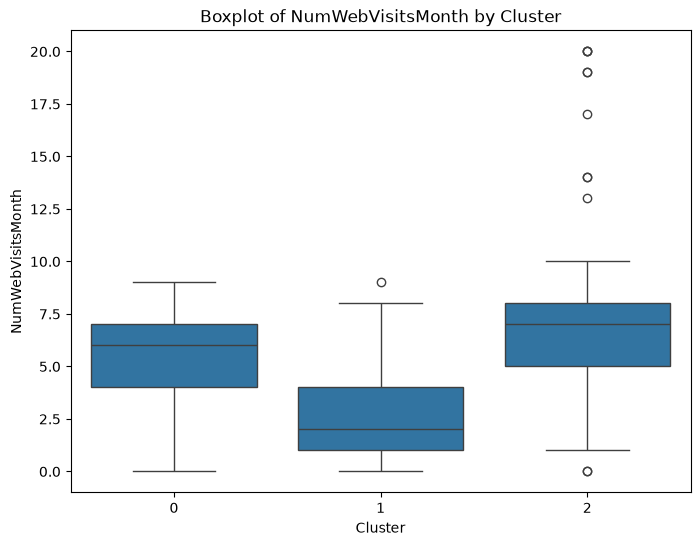

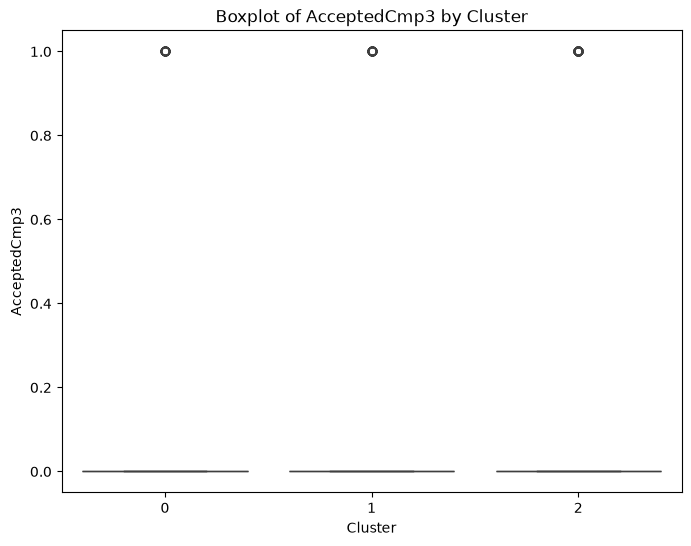

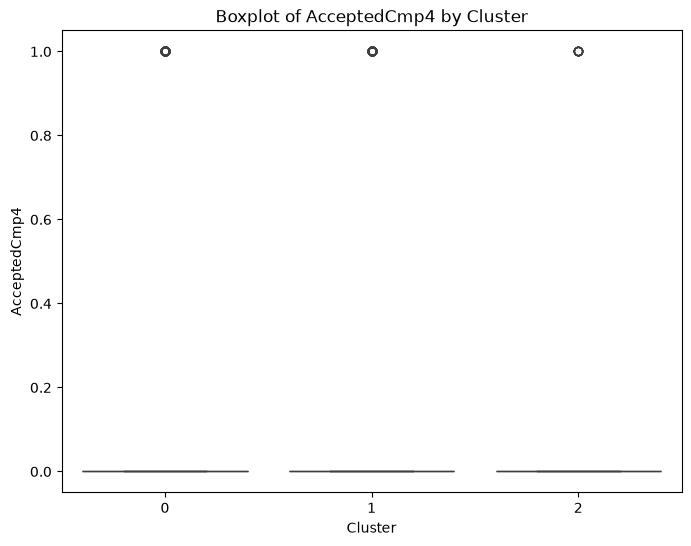

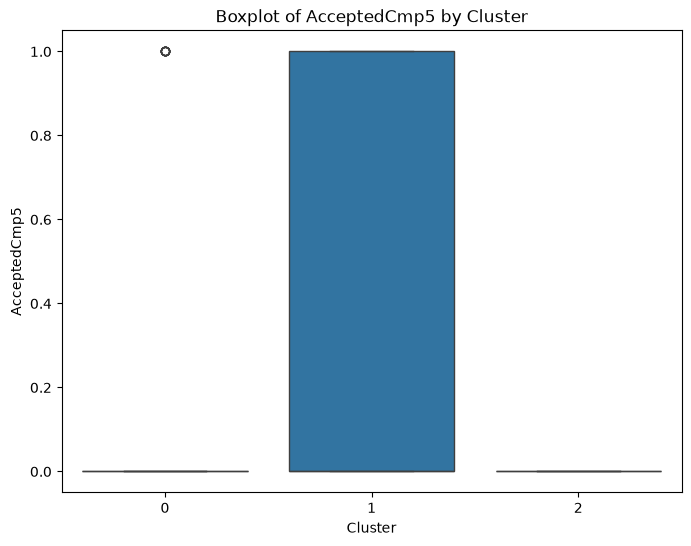

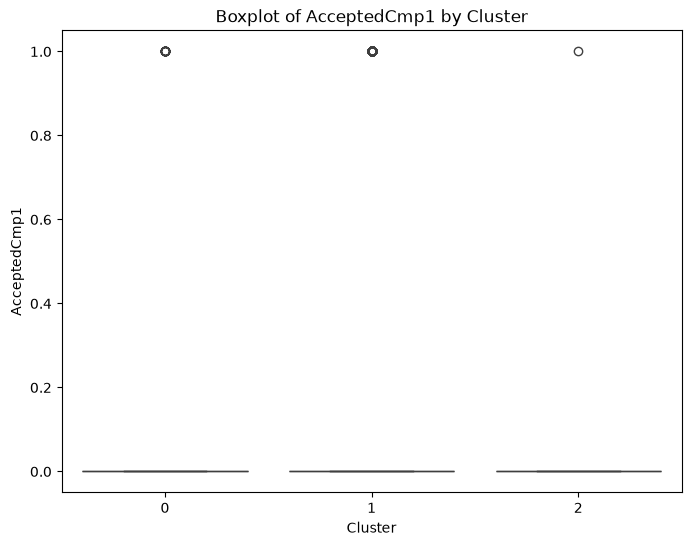

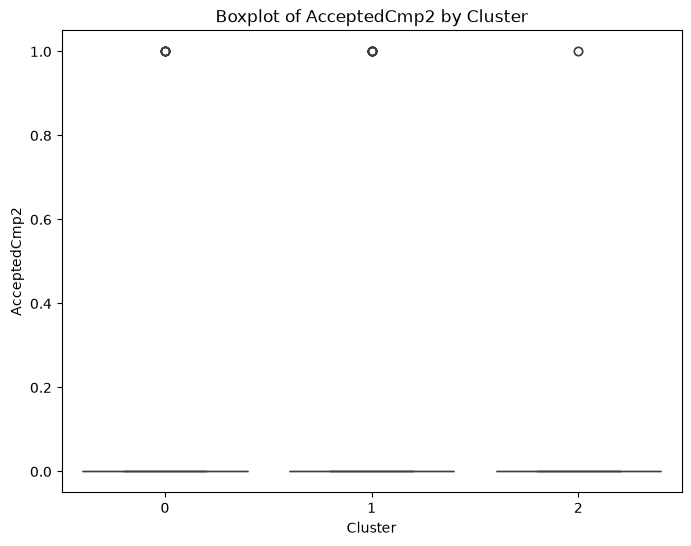

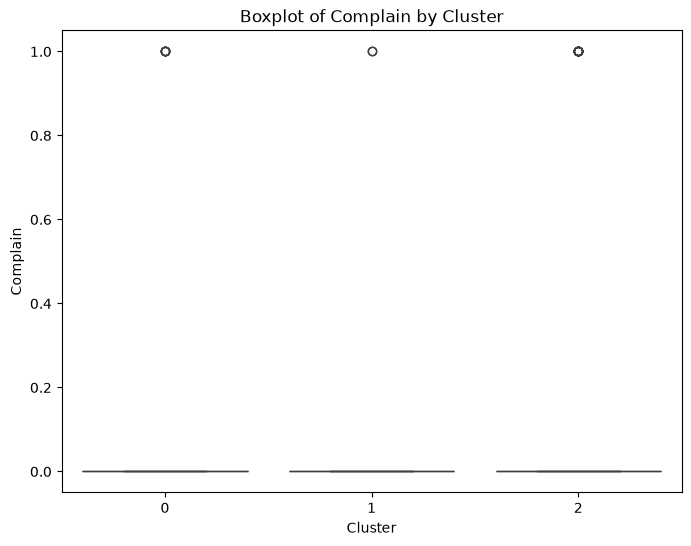

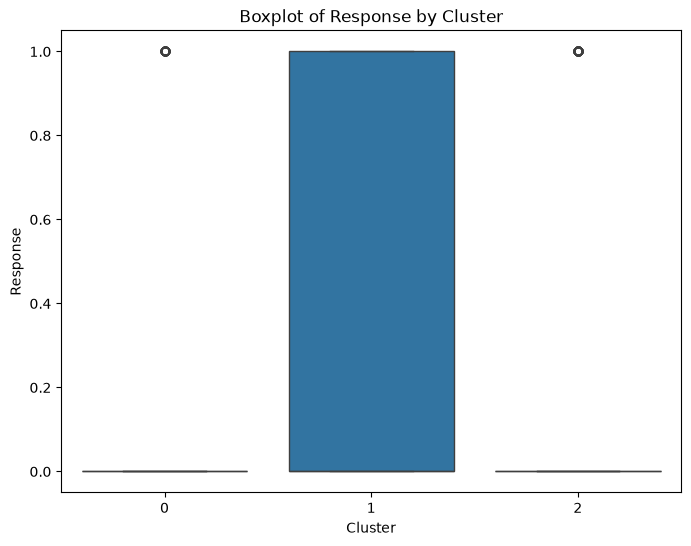

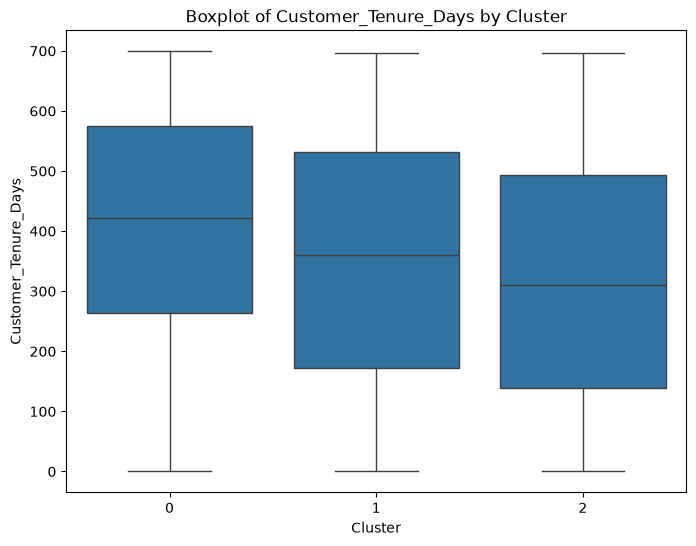

In [ ]:
for column in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=viz_df_scaled, x="Cluster", y=column)
    plt.title(f"Boxplot of {column} by Cluster")
    plt.show()

In [ ]:
raw_df.loc[
    raw_df["Year_Birth"] <= 1900,
    ["Year_Birth", "Income", "MntWines", "MntMeatProducts"],
]

,Year_Birth,Income,MntWines,MntMeatProducts
192,1900,36640.0,15,8
239,1893,60182.0,8,5
339,1899,83532.0,755,562


In [85]:
outlier_mask = raw_df["Year_Birth"] <= 1900

raw_df = raw_df.loc[~outlier_mask].copy()
print(f"Видалено рядків: {outlier_mask.sum()}; залишилося: {len(raw_df)}")

Видалено рядків: 0; залишилося: 2236


In [ ]:
X = prepare_clustering_features(raw_df, cat_cols)
X_scaled = prepare_clustering_features(raw_df, cat_cols, scale_numeric=True)

print(X_scaled.shape)

(2236, 35)


Вирішила видалити три записи з роками народження 1893, 1899 і 1900 як імовірні помилки.А аномальний дохід 666666 я видалила ще раніше.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

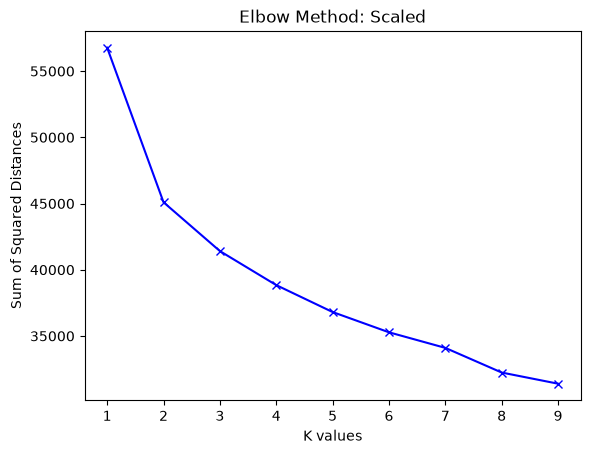

   k  silhouette
1  2    0.237819
2  3    0.163394
3  4    0.166910
4  5    0.168371
5  6    0.100698
6  7    0.104213
7  8    0.105367
8  9    0.099302


In [ ]:
kmeans_results_scaled = evaluate_kmeans(
    X_scaled,
    range(1, 10),
    silhouette_k_values=range(2, 10),
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)
plot_elbow(kmeans_results_scaled, title="Elbow Method: Scaled")
print(kmeans_results_scaled.dropna(subset=["silhouette"])[["k", "silhouette"]])

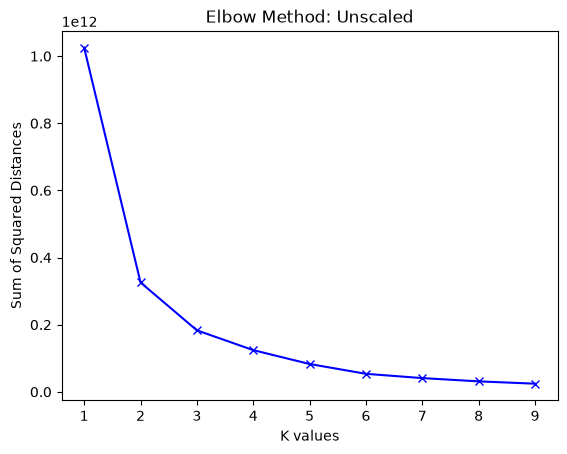

   k  silhouette
1  2    0.598367
2  3    0.544000
3  4    0.524386
4  5    0.534239
5  6    0.541053
6  7    0.517437
7  8    0.515626
8  9    0.519435


In [ ]:
kmeans_results = evaluate_kmeans(
    X,
    range(1, 10),
    silhouette_k_values=range(2, 10),
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)
plot_elbow(kmeans_results, title="Elbow Method: Unscaled")
print(kmeans_results.dropna(subset=["silhouette"])[["k", "silhouette"]])

Silhouette for k=2: 0.598


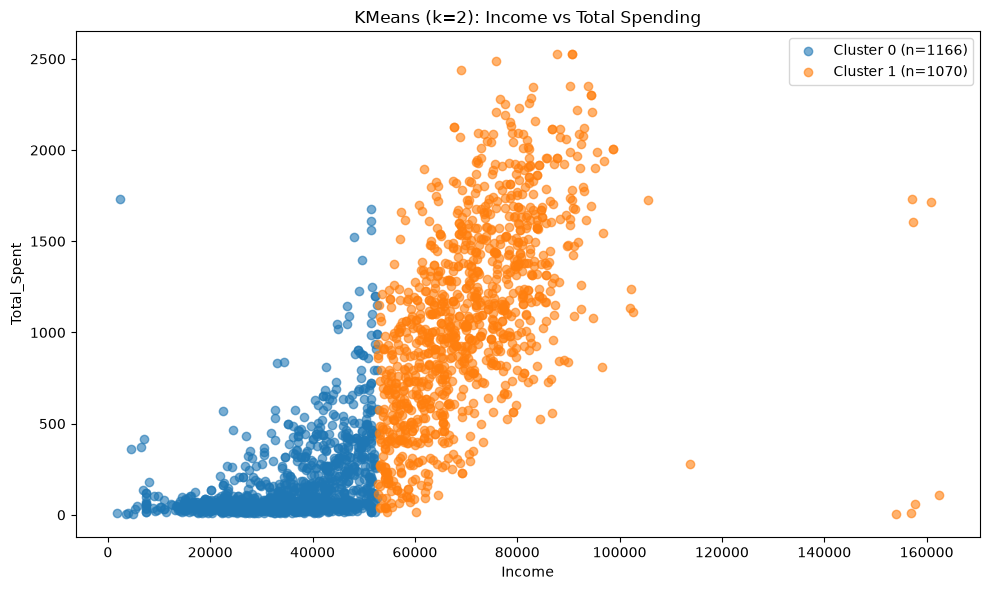

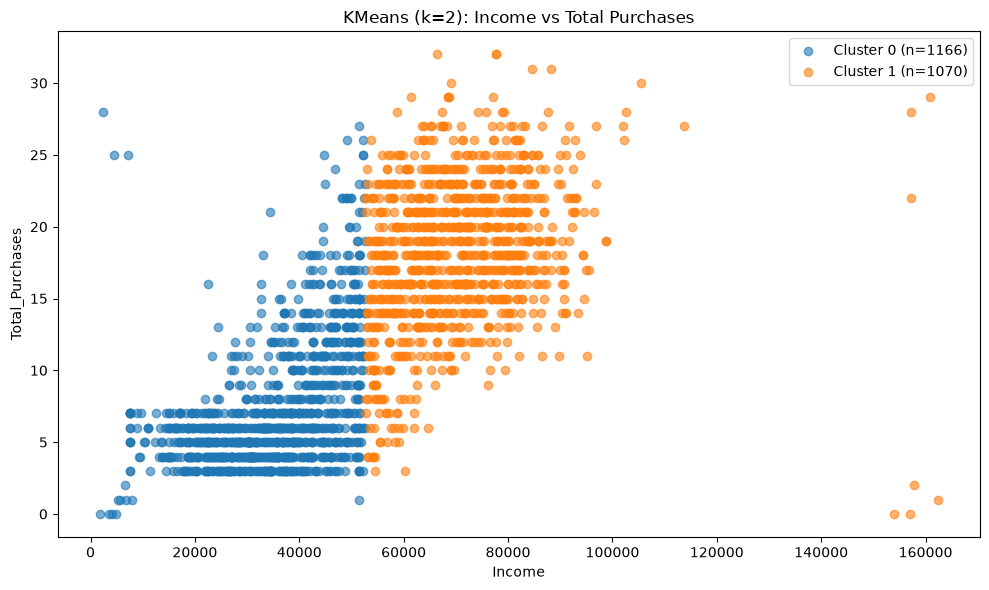

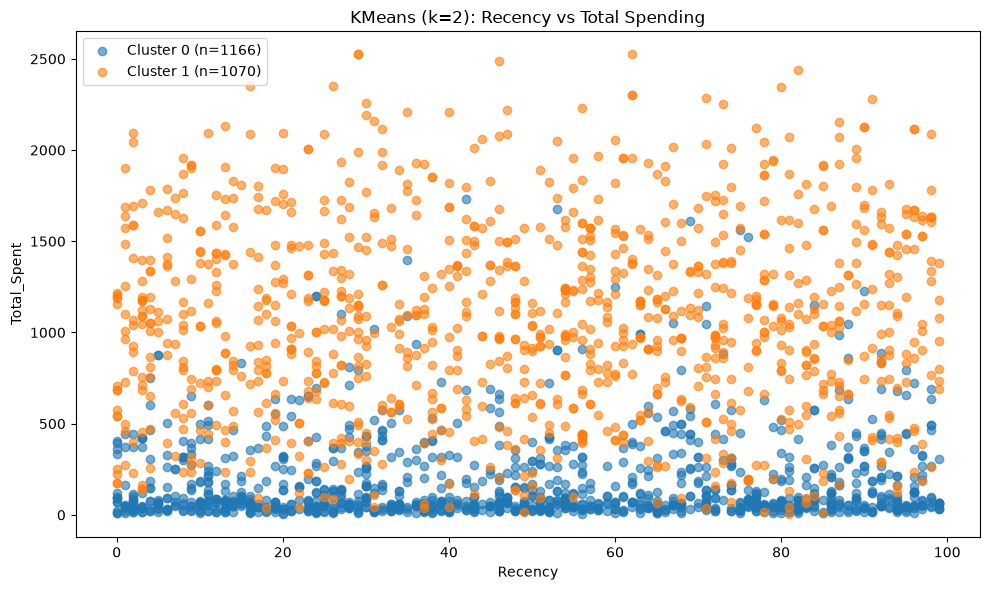

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
0             1166    35013.045     174.038           7.376           0.011
1             1070    70411.805    1076.690          18.181           0.007


In [ ]:
best_kmeans, best_labels, best_silhouette = fit_kmeans(
    X,
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)
print(f"Silhouette for k=2: {best_silhouette:.3f}")

best_viz_df = prepare_cluster_viz_df(raw_df, best_labels)
plot_customer_clusters(best_viz_df, title="KMeans (k=2)")
print(summarize_customer_clusters(best_viz_df).round(3))

Silhouette for k=2: 0.238


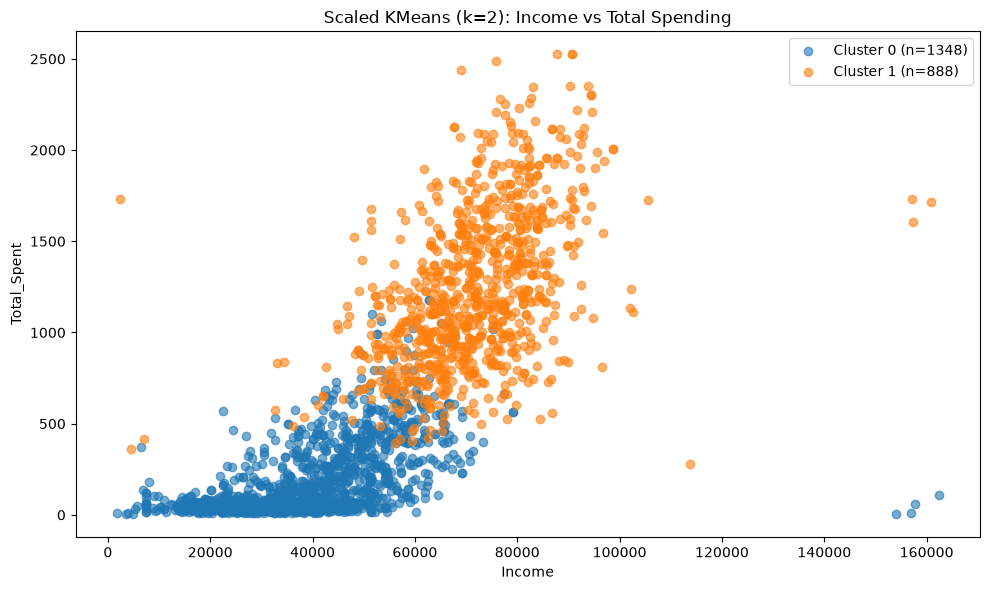

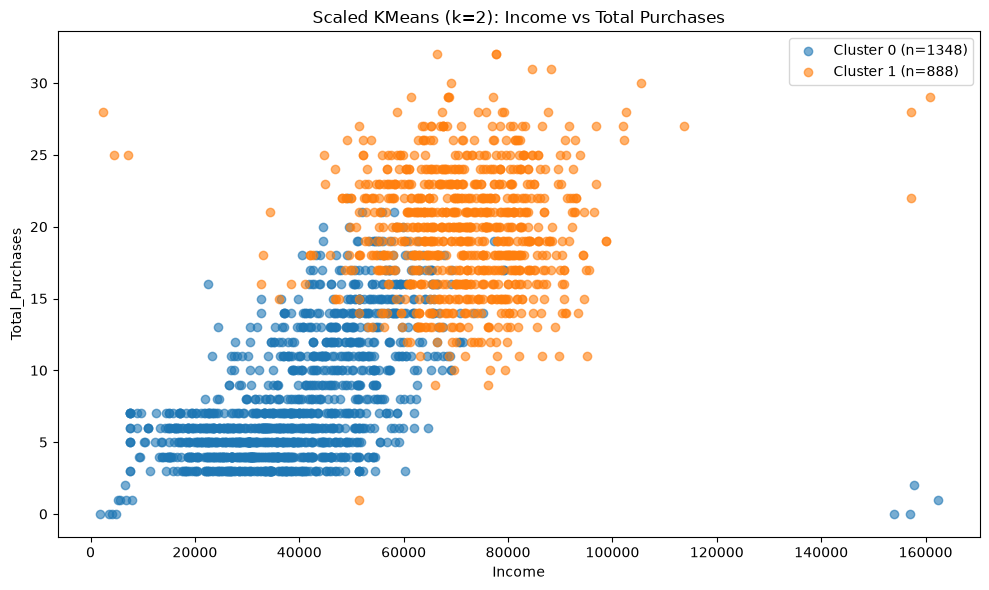

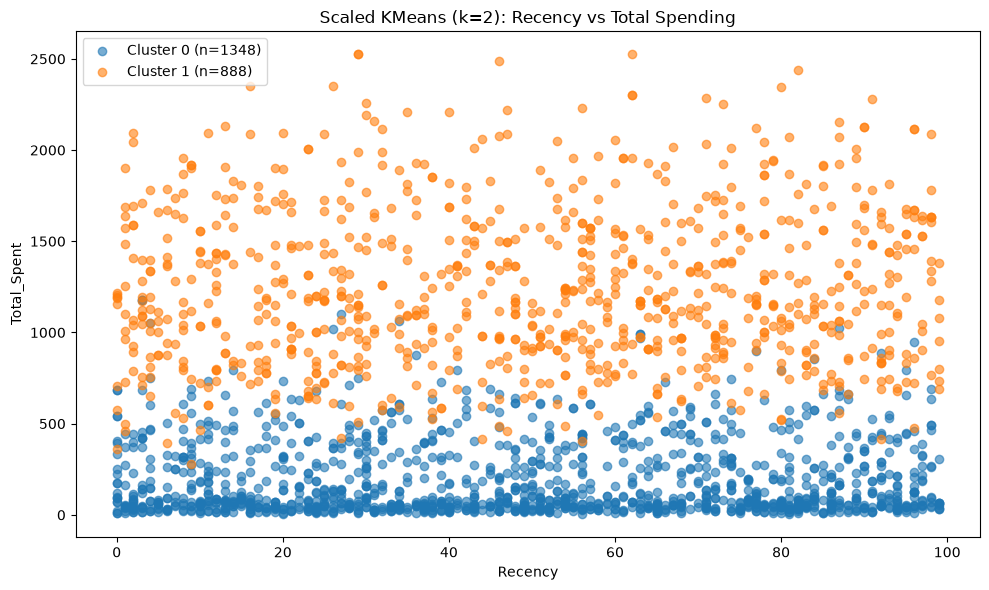

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
0             1348    39109.151     187.678           7.828           0.010
1              888    71448.992    1240.986          19.709           0.008


In [ ]:
best_kmeans_scaled, best_labels_scaled, best_silhouette_scaled = fit_kmeans(
    X_scaled,
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)
print(f"Silhouette for k=2: {best_silhouette_scaled:.3f}")

best_viz_df_scaled = prepare_cluster_viz_df(raw_df, best_labels_scaled)
plot_customer_clusters(best_viz_df_scaled, title="Scaled KMeans (k=2)")
print(summarize_customer_clusters(best_viz_df_scaled).round(3))

На немасштабованих та масштабованих даних основний перегин Elbow спостерігається біля k=2. Знову вищий силует спостерігаю саме на немасштабованих даних, як в попередньому завданні.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

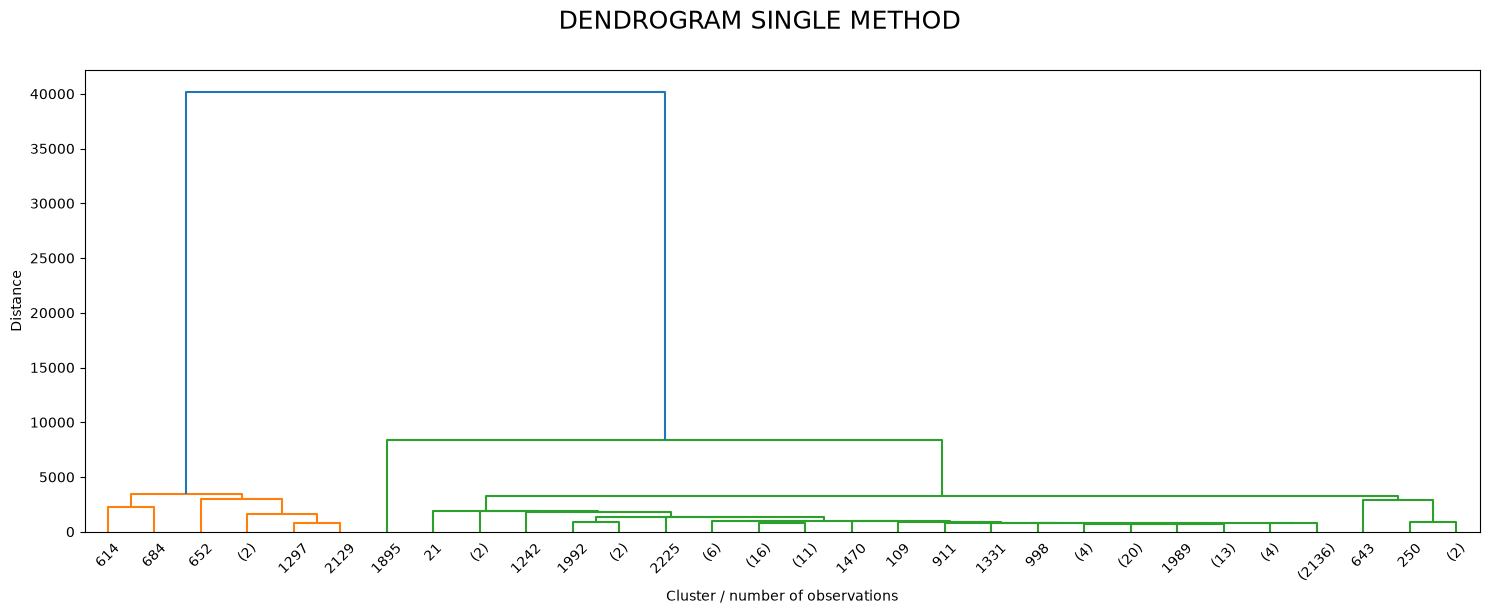

In [ ]:
dist_sin = linkage(X, method="single")
plt.figure(figsize=(18, 6))
dendrogram(dist_sin, truncate_mode="lastp")
plt.xlabel("Cluster / number of observations")
plt.ylabel("Distance")
plt.suptitle("DENDROGRAM SINGLE METHOD", fontsize=18)
plt.show()

k=2: silhouette=0.766
1       7
2    2229
Name: count, dtype: int64


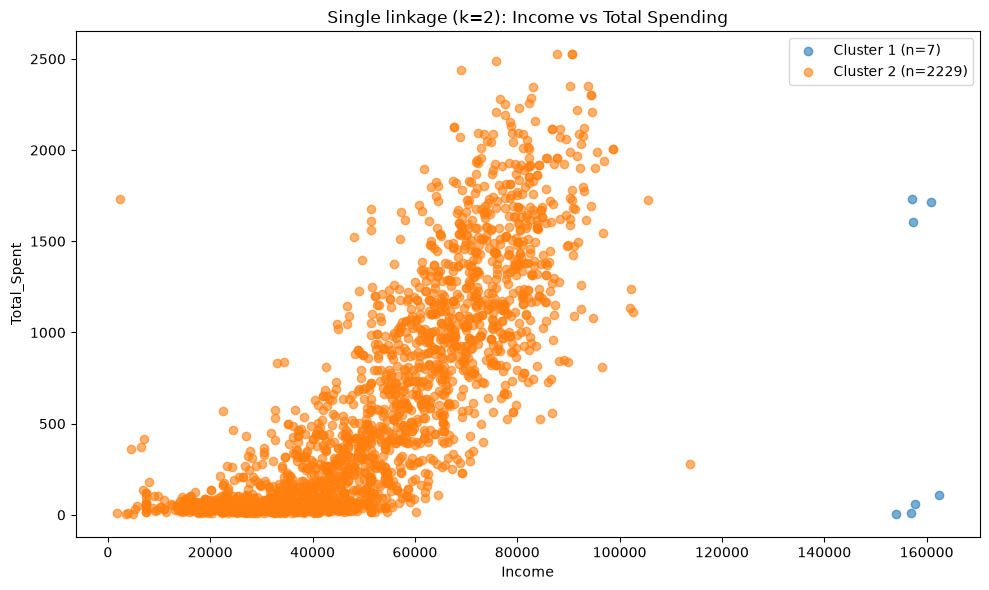

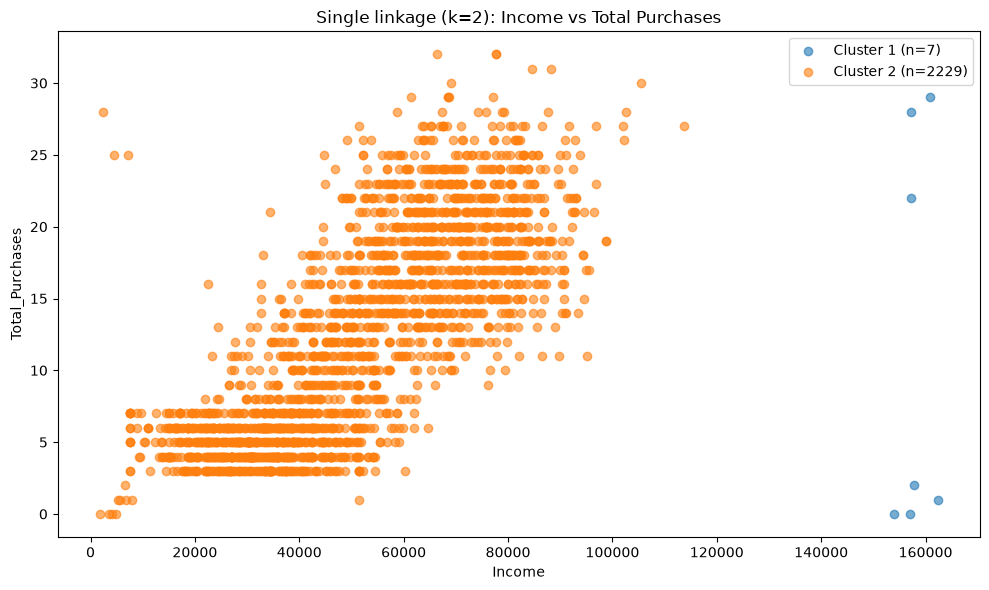

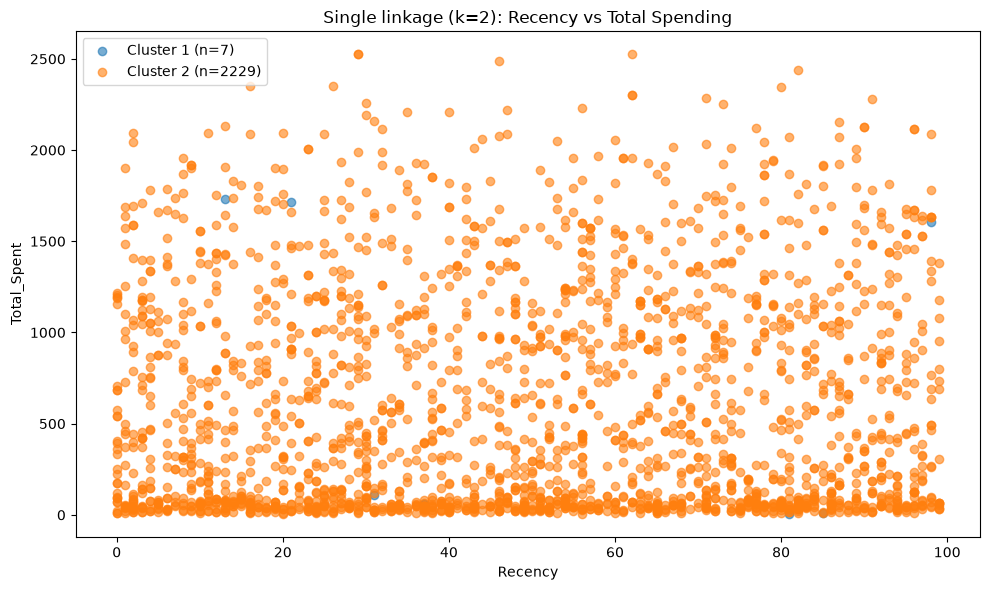

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
1                7   158024.286     747.857          11.714           0.000
2             2229    51619.413     605.541          12.549           0.009
k=3: silhouette=0.559
1       7
2    2228
3       1
Name: count, dtype: int64


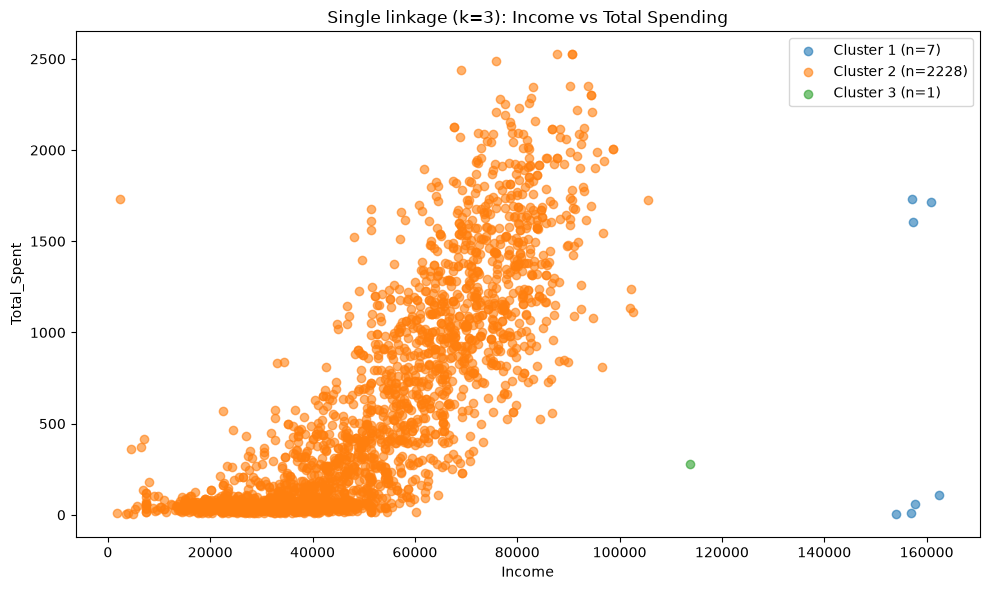

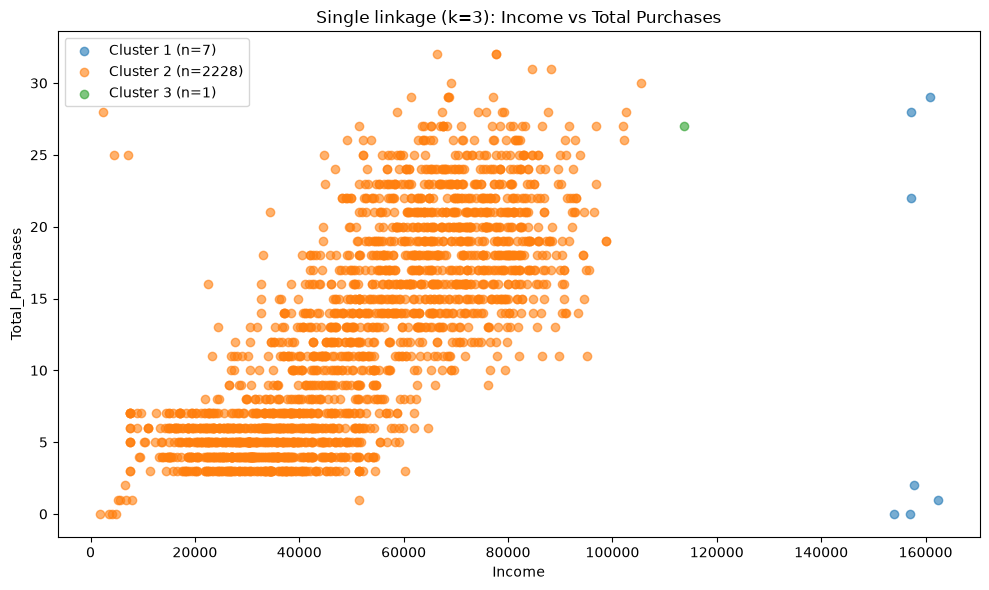

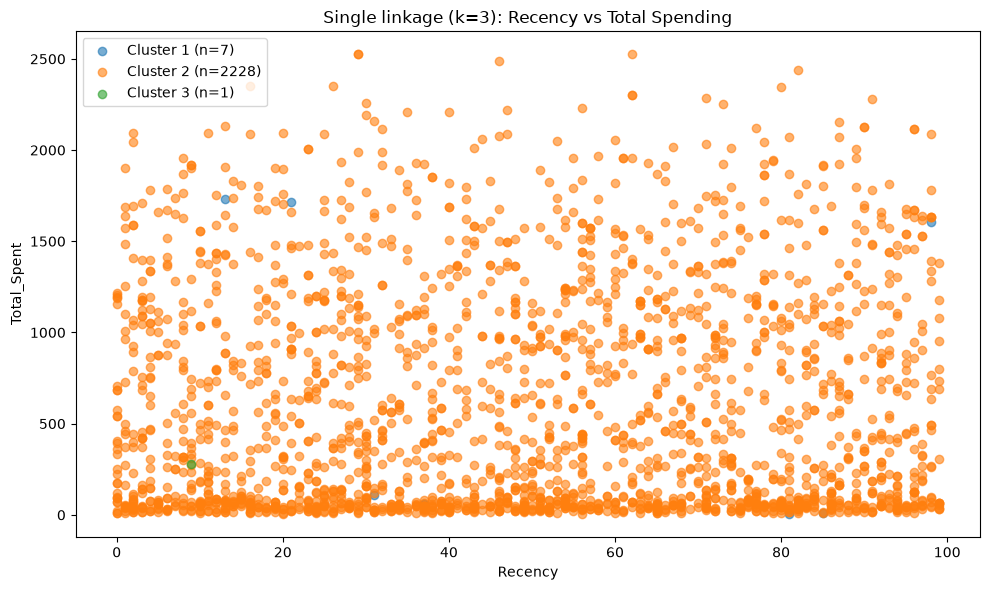

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
1                7   158024.286     747.857          11.714           0.000
2             2228    51591.534     605.689          12.543           0.009
3                1   113734.000     277.000          27.000           0.000


In [ ]:
for k in [2, 3]:
    hierarchical_labels = fcluster(
        dist_sin,
        t=k,
        criterion="maxclust",
    )

    score = metrics.silhouette_score(X, hierarchical_labels)

    print(f"k={k}: silhouette={score:.3f}")
    print(pd.Series(hierarchical_labels).value_counts().sort_index())

    hierarchical_viz_df = prepare_cluster_viz_df(
        raw_df,
        hierarchical_labels,
    )

    plot_customer_clusters(
        hierarchical_viz_df,
        title=f"Single linkage (k={k})",
    )
    print(summarize_customer_clusters(hierarchical_viz_df).round(3))

Попри високий силует, поділ на 2 і 3 кластери вийшов не дуже корисним: більшість клієнтів потрапила в один кластер, а окремо виділилися клієнти з високими доходами. Тому цей метод не допоміг виділити змістовні групи клієнтів.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [ ]:
results = []

for eps in [0.5, 1, 1.5, 2, 3, 4, 5]:
    for min_samples in [5, 10, 20]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = model.fit_predict(X_scaled)

        mask = labels_db != -1
        clustered_labels = labels_db[mask]
        n_clusters = len(set(clustered_labels))

        silhouette = np.nan
        if 2 <= n_clusters < mask.sum():
            silhouette = metrics.silhouette_score(
                X_scaled.loc[mask],
                clustered_labels,
            )

        results.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_pct": (~mask).mean() * 100,
                "silhouette": silhouette,
            }
        )

dbscan_results = pd.DataFrame(results)

dbscan_results.sort_values(
    "silhouette",
    ascending=False,
).round(3)

,eps,min_samples,n_clusters,noise_pct,silhouette
3,1.0,5,2,99.419,0.561
19,5.0,10,2,5.098,0.493
18,5.0,5,5,3.309,0.360
14,3.0,20,2,42.844,0.294
16,4.0,10,3,15.921,0.245
15,4.0,5,9,11.852,0.220
7,1.5,10,3,95.528,0.190
12,3.0,5,5,31.485,0.167
13,3.0,10,4,35.555,0.160
6,1.5,5,16,88.640,0.140


In [ ]:
dbscan = DBSCAN(eps=5.0, min_samples=10)
dbscan.fit(X_scaled)
labels_db = dbscan.labels_
print(labels_db)

[0 0 0 ... 0 0 0]


In [ ]:
cluster_counts = pd.Series(dbscan.labels_, name="Cluster").value_counts().sort_index()

print("Кількість клієнтів у кожному кластері:")
print(cluster_counts)
print("-1 — шум, а не окремий кластер.")
print(f"Частка шуму: {(labels_db == -1).mean():.2%}")

Кількість клієнтів у кожному кластері:
Cluster
-1     114
 0    2106
 1      16
Name: count, dtype: int64
-1 — шум, а не окремий кластер.
Частка шуму: 5.10%


In [ ]:
noise_mask = labels_db == -1
clustered_X = X_scaled.loc[~noise_mask]
clustered_labels = labels_db[~noise_mask]
n_clusters_db = len(set(clustered_labels))

if 2 <= n_clusters_db < len(clustered_X):
    silhouette_db = metrics.silhouette_score(clustered_X, clustered_labels)
    print(f"Силует без шуму: {silhouette_db:.3f}")
else:
    silhouette_db = np.nan
    print("Силует не визначений: потрібні від 2 до n_samples - 1 кластерів.")

Силует без шуму: 0.493


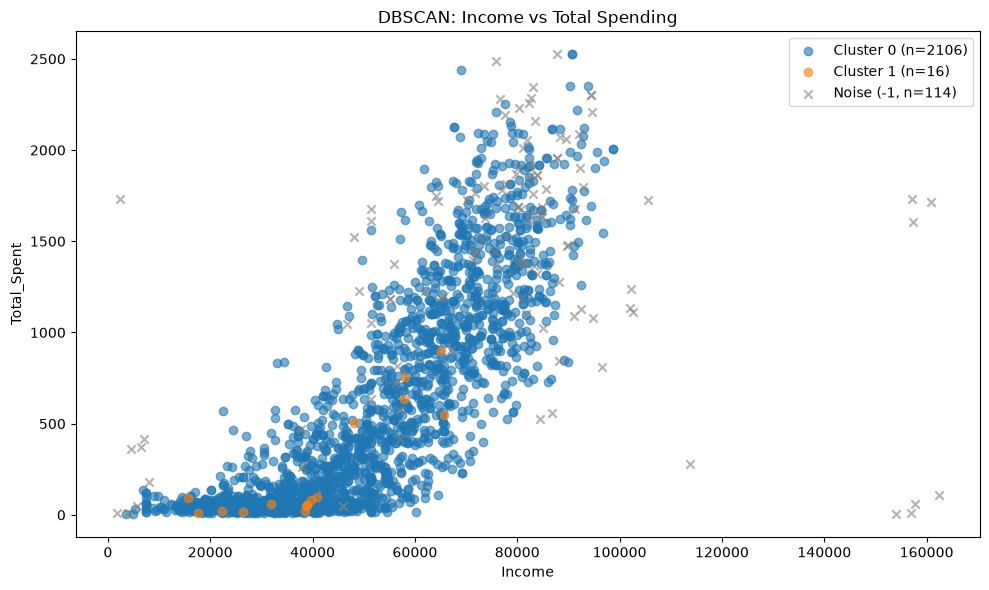

         customers  mean_income  mean_spent  mean_purchases  complain_share
Cluster                                                                    
-1             114    77133.904    1361.895          18.544           0.035
 0            2106    50678.141     567.818          12.253           0.000
 1              16    40275.750     244.062           8.438           1.000


In [ ]:
dbscan_viz_df = prepare_cluster_viz_df(
    raw_df,
    dbscan.labels_,
)

plot_clusters(
    dbscan_viz_df,
    x_col="Income",
    y_col="Total_Spent",
    title="DBSCAN: Income vs Total Spending",
)
print(summarize_customer_clusters(dbscan_viz_df).round(3))

Для DBSCAN обрала eps=5 і min_samples=10 як компроміс між силуетом і часткою шуму. Варіант eps=1 має вищий силует, але відкидає понад 99% клієнтів.

DBSCAN об’єднав більшість клієнтів в один кластер, а в маленький виділив клієнтів, які скаржилися (Complain = 1 у таблиці профілів). Попри відносно високий силует без шуму, корисного поділу за купівельною поведінкою не отримано. Тому цей варіант вважаю невдалим для сегментації.